In [1]:
!pip install tf_keras

In [19]:
import os
import pandas as pd
import numpy as np
import datetime
import random

import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as tfk

from IPython.display import Image
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [20]:
import os
print(os.listdir("/kaggle/input"))

['competitions', 'models']


In [21]:
import os

train_dir = "/kaggle/input/competitions/dog-breed-identification/train"
labels_path = "/kaggle/input/competitions/dog-breed-identification/labels.csv"

labels = pd.read_csv(labels_path)

labels["filepath"] = labels["id"].apply(
    lambda x: os.path.join(train_dir, x + ".jpg")
)

labels.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,/kaggle/input/competitions/dog-breed-identific...
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,/kaggle/input/competitions/dog-breed-identific...
2,001cdf01b096e06d78e9e5112d419397,pekinese,/kaggle/input/competitions/dog-breed-identific...
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,/kaggle/input/competitions/dog-breed-identific...
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,/kaggle/input/competitions/dog-breed-identific...


In [22]:
print("Total Images :", len(labels))

Total Images : 10222


In [23]:
len(labels['breed'].unique())

120

In [24]:
breed = labels.groupby(by='breed').agg({'id':'count'})
breed.sort_values(by='id', ascending=False).head(10)

,id
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114
shih-tzu,112
pomeranian,111
great_pyrenees,111
basenji,110


In [25]:
filenames = ['/kaggle/input/dog-breed-identification/train/' + fname + '.jpg' for fname in labels['id'] ]
len(filenames)

10222

In [26]:
if len(os.listdir('/kaggle/input/competitions/dog-breed-identification/train')) == len(filenames):
    print('Great!, one step more to be sure that we have matched data')
else:
    print('check train folder')

Great!, one step more to be sure that we have matched data


In [27]:
X = filenames
y = labels['breed']

In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

labels["breed_encoded"] = label_encoder.fit_transform(labels["breed"])

encoding_labels = label_encoder.classes_

print(len(encoding_labels))

120


In [50]:
labels.head()

,id,breed,filepath,breed_encoded
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,/kaggle/input/competitions/dog-breed-identific...,19
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,/kaggle/input/competitions/dog-breed-identific...,37
2,001cdf01b096e06d78e9e5112d419397,pekinese,/kaggle/input/competitions/dog-breed-identific...,85
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,/kaggle/input/competitions/dog-breed-identific...,15
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,/kaggle/input/competitions/dog-breed-identific...,49


In [51]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(
    labels["breed_encoded"].values,
    num_classes=120
)

In [52]:
from sklearn.model_selection import train_test_split

X = labels["filepath"].values

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# y = pd.get_dummies(y)
# encoding_labels = y.columns
# y=y.to_numpy()

In [54]:
img_size = 224
batch_size = 32

def prepare_image(image_path):
    '''
    turns an image into a tensor
    '''
    # read an image
    image = tf.io.read_file(image_path)
    # turn an image to numerical version
    image = tf.image.decode_jpeg(image, channels=3)
    # convert colours from 0-255 to 0-1
    image = tf.image.convert_image_dtype(image, tf.float32)
    # resize
    image = tf.image.resize(image, size=[img_size, img_size])
    
    return image

In [55]:
def get_label_image(image_path, label):
    image = prepare_image(image_path)
    
    return image, label

In [56]:
def create_batches(X, y=None, batch_size=batch_size, valid_data=False, test_data=False):
    '''
    split a dataset to batches
    '''
    if test_data:
        data = tf.data.Dataset.from_tensor_slices(tf.constant(X))
        data_batch = data.map(prepare_image).batch(batch_size)
    elif valid_data:
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data_batch = data.map(get_label_image).batch(batch_size)
    else:
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data = data.shuffle(buffer_size=len(X))
        data_batch = data.map(get_label_image).batch(batch_size)
    
    return data_batch

In [57]:
train_data = create_batches(X_train, y_train)
valid_data = create_batches(X_val, y_val, valid_data=True)

In [58]:
train_data = create_batches(X_train, y_train)

valid_data = create_batches(
    X_val,
    y_val,
    valid_data=True
)

In [59]:
input_shape = [None, img_size, img_size, 3]
output_shape = len(encoding_labels)
model_url = "https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1"

# number of epochs for training
num_epochs = 10

In [60]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [61]:
import tf_keras

def create_tf_callback():
    logdir = os.path.join(
        '/kaggle/working/',
        datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
    )

    return tf_keras.callbacks.TensorBoard(
        log_dir=logdir
    )


early_stopping = tf_keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3
)

In [62]:
def create_model(input_shape=input_shape, output_shape=output_shape, model_url=model_url):
    print('create a model with: ', model_url)
    
    # setup the model
    model = tfk.Sequential([
        hub.KerasLayer(model_url),
                       tfk.layers.Dense(units=output_shape, activation='softmax')
                       ])
    
    # compile the model
    model.compile(
        loss=tfk.losses.CategoricalCrossentropy(), 
        optimizer=tfk.optimizers.Adam(), 
        metrics=['accuracy'] 
    )
    
    # build the model
    model.build(input_shape)
    
    return model

In [63]:
def train_model():
    # model creation
    model = create_model()

    # model training
    model.fit(
        x=train_data,
        epochs=num_epochs,
        validation_data=valid_data,
        validation_freq=1,
        callbacks=[early_stopping]
    )

    return model

In [64]:
model = train_model()
print('\nModel Summary:')
model.summary()

create a model with:  https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1
Epoch 1/10
256/256 [==============================] - 177s 681ms/step - loss: 1.5219 - accuracy: 0.6351 - val_loss: 0.7144 - val_accuracy: 0.7936
Epoch 2/10
256/256 [==============================] - 179s 701ms/step - loss: 0.4161 - accuracy: 0.8795 - val_loss: 0.6481 - val_accuracy: 0.8093
Epoch 3/10
256/256 [==============================] - 173s 677ms/step - loss: 0.2347 - accuracy: 0.9398 - val_loss: 0.6447 - val_accuracy: 0.8059
Epoch 4/10
256/256 [==============================] - 175s 682ms/step - loss: 0.1505 - accuracy: 0.9665 - val_loss: 0.6522 - val_accuracy: 0.8093
Epoch 5/10
256/256 [==============================] - 173s 677ms/step - loss: 0.1008 - accuracy: 0.9839 - val_loss: 0.6484 - val_accuracy: 0.8127
Epoch 6/10
256/256 [==============================] - 174s 681ms/step - loss: 0.0753 - accuracy: 0.9883 - val_loss: 0.6788 - val_accuracy: 0.8039
Epoch 7/10
256/256 

In [65]:
y_pred = model.predict(valid_data)

64/64 [==============================] - 35s 540ms/step


In [66]:
def create_model(input_shape=input_shape, output_shape=output_shape, model_url=model_url):
    print('create a model with: ', model_url)
    
    # setup the model
    model = tfk.Sequential([
        hub.KerasLayer(model_url),
                       tfk.layers.Dense(units=output_shape, activation='softmax')
                       ])
    
    # compile the model
    model.compile(
        loss=tfk.losses.CategoricalCrossentropy(), 
        optimizer=tfk.optimizers.Adam(), 
        metrics=['accuracy'] 
    )
    
    # build the model
    model.build(input_shape)
    
    return model

In [67]:
def pred_labels(prediction_propabilities):
    
    return encoding_labels[np.argmax(prediction_propabilities)]

Is golden_retriever predicted properly? Prediction: golden_retriever. So:  True



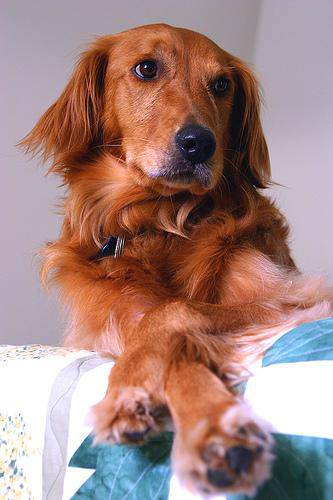

In [68]:
index = random.randint(0, len(y_val))
label = pred_labels(y_pred[index])

print(f'Is {label} predicted properly? Prediction: {pred_labels(y_val[index])}. So:  {label==pred_labels(y_val[index])}\n')

Image(X_val[index])

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# create batches
# train data
train_data = create_batches(X_train, y_train)

# test data
valid_data = create_batches(X_val, y_val, valid_data=True)

print(len(X_train), len(X_val), len(y_train), len(y_val))

In [71]:
model2 = train_model()

print('\nModel Summary:')
model.summary()

create a model with:  https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1
Epoch 1/10
256/256 [==============================] - 177s 683ms/step - loss: 1.4717 - accuracy: 0.6428 - val_loss: 0.7423 - val_accuracy: 0.7814
Epoch 2/10
256/256 [==============================] - 175s 684ms/step - loss: 0.4036 - accuracy: 0.8821 - val_loss: 0.6968 - val_accuracy: 0.7848
Epoch 3/10
256/256 [==============================] - 174s 679ms/step - loss: 0.2315 - accuracy: 0.9374 - val_loss: 0.6849 - val_accuracy: 0.7922
Epoch 4/10
256/256 [==============================] - 181s 706ms/step - loss: 0.1437 - accuracy: 0.9697 - val_loss: 0.6806 - val_accuracy: 0.7892
Epoch 5/10
256/256 [==============================] - 181s 709ms/step - loss: 0.0972 - accuracy: 0.9836 - val_loss: 0.6892 - val_accuracy: 0.7912
Epoch 6/10
256/256 [==============================] - 175s 685ms/step - loss: 0.0683 - accuracy: 0.9929 - val_loss: 0.6957 - val_accuracy: 0.7883

Model Summary:
Mod

Is flat-coated_retriever predicted properly? Prediction: redbone. So:  False



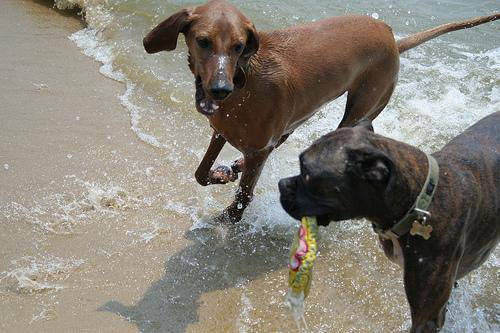

In [75]:
index = random.randint(20, len(y_val))
label = pred_labels(y_pred[index])

print(f'Is {label} predicted properly? Prediction: {pred_labels(y_val[index])}. So:  {label==pred_labels(y_val[index])}\n')

Image(X_val[index])